<div style="
    background: #0f3460;
    padding: 14px 48px;
    border-left: 5px solid #e94560;
    font-family: 'Segoe UI', sans-serif;
    width: 100vw;
    box-sizing: border-box;
    position: relative;
    left: 50%;
    transform: translateX(-50%);
    overflow: hidden;
">
    <p style="color: rgba(255,255,255,0.5); font-size: 0.75em; margin: 0 0 4px 0;
       letter-spacing: 2px; text-transform: uppercase;">
        Nhập môn học máy &nbsp;|&nbsp; Báo cáo Đồ án 3 &nbsp;|&nbsp; CQ2023/24
    </p>
    <div style="display: flex; align-items: baseline; gap: 20px; flex-wrap: wrap;">
        <div>
            <h1 style="color: #ffffff; font-size: 1.4em; margin: 0 0 2px 0; font-weight: 700;">
                Notebook: NequIP Ablation Study — Learning Curves
            </h1>
            <p style="color: #89b4fa; font-size: 0.88em; margin: 0;">
                E(3)-Equivariant GNN &middot; QM9 Energy Prediction &middot; Invariant vs Equivariant &middot; Tensor Product &middot; Clebsch-Gordan
            </p>
        </div>
        <span style="color: rgba(255,255,255,0.5); font-size: 0.8em; margin-left: auto; white-space: nowrap;">
            2 models &nbsp;&middot;&nbsp; 2 dataset sizes &nbsp;&middot;&nbsp; QM9 dataset
        </span>
    </div>
</div>


## **Table of Content**

- [1. Bài toán và đặc điểm của dữ liệu phân tử](#sec-1)
- [2. Nền tảng toán học](#sec-2)
  - [2.1 Nhóm Euclid E(3) và tính tương biến](#sec-2-1)
  - [2.2 Hàm điều hòa cầu và biểu diễn bất khả quy](#sec-2-2)
  - [2.3 Tích tensor và hệ số Clebsch-Gordan](#sec-2-3)
  - [2.4 Bất biến vs tương biến: vai trò của $\ell_{\max}$](#sec-2-4)
- [3. Chuẩn bị dữ liệu](#sec-3)
  - [3.1 Tập dữ liệu QM9](#sec-3-1)
  - [3.2 Trực quan phân tử mẫu](#sec-3-2)
  - [3.3 Chia tập con và xây dựng đồ thị](#sec-3-3)
- [4. Kiến trúc NequIP](#sec-4)
  - [4.1 Truyền thông điệp tương biến](#sec-4-1)
  - [4.2 Cấu hình thí nghiệm so sánh](#sec-4-2)
- [5. Huấn luyện](#sec-5)
  - [5.1 Cấu hình huấn luyện](#sec-5-1)
  - [5.2 Thu thập kết quả từ log](#sec-5-2)
- [6. Đánh giá và so sánh](#sec-6)
  - [6.1 Bảng tổng hợp kết quả](#sec-6-1)
  - [6.2 Đường cong học (thang log-log)](#sec-6-2)
  - [6.3 Training và validation loss theo epoch](#sec-6-3)
  - [6.4 So sánh MAE và RMSE cuối cùng](#sec-6-4)
  - [6.5 Phân tích kết quả](#sec-6-5)
- [7. Kết luận](#sec-7)


Paper gốc: Batzner et al., "E(3)-equivariant graph neural networks for data-efficient and accurate interatomic potentials", Nature Communications 2022.

Mở rộng: Liao & Smidt, "Equiformer: Equivariant Graph Attention Transformer for 3D Atomistic Graphs", ICLR 2023.

Notebook này đi theo hướng 3 của đồ án: sử dụng NequIP/EGNN trên QM9, đại diện cho hướng constructed models dành cho dữ liệu đồ thị không gian, xử lý tính tương biến với nhóm liên tục E(3) bao gồm dịch chuyển, quay và phản xạ. Notebook trình bày từ bài toán, nền tảng toán học, thí nghiệm so sánh bất biến ($\ell_{\max}=0$) vs tương biến ($\ell_{\max}=1$).


## **Import thư viện cần thiết**

In [1]:
# Thư viện chuẩn 
import os
import sys
import csv
import logging
import threading
import importlib
from pathlib import Path
from typing import Dict, List, Optional

# Tính toán 
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform

# Trực quan hóa
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D

# Deep Learning (PyTorch)
import torch


In [2]:
NOTEBOOK_DIR = Path('.')
CONFIGS_DIR  = NOTEBOOK_DIR / '..' / 'configs'
OUTPUTS_DIR  = NOTEBOOK_DIR / '..' / 'outputs'
FIG_DIR      = NOTEBOOK_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)



## <a id="sec-1"></a>**1. Bài toán và đặc điểm của dữ liệu phân tử**

Trong hóa học tính toán, một bài toán quan trọng là dự đoán năng lượng và lực tương tác giữa các nguyên tử trong phân tử. Mô phỏng cổ điển dùng DFT cho kết quả chính xác nhưng chi phí tính toán rất lớn, đặc biệt khi phân tử chứa nhiều nguyên tử.

GNN cho phép học trực tiếp hàm thế năng liên nguyên tử từ dữ liệu. Mỗi phân tử được biểu diễn dưới dạng đồ thị không gian:

- Mỗi nguyên tử là một nút với tọa độ 3D trong không gian
- Cạnh nối hai nguyên tử nằm trong bán kính cutoff $r_{\max}$
- Đặc trưng cạnh mã hóa khoảng cách và hướng tương đối giữa hai nguyên tử

Với dữ liệu 3D, vật lý yêu cầu:

1. *Tính bất biến dịch chuyển*: năng lượng không thay đổi khi dịch chuyển phân tử trong không gian
2. *Tính bất biến quay*: năng lượng không thay đổi khi quay phân tử
3. *Tính bất biến phản xạ*: năng lượng không thay đổi khi phản chiếu phân tử

Ba yêu cầu trên chính là tính bất biến dưới nhóm Euclid $E(3)$. NequIP giải quyết vấn đề này bằng cách xây dựng kiến trúc mạng có tính tương biến với $E(3)$, đảm bảo đầu ra tuân thủ đúng các đối xứng vật lý.



## <a id="sec-2"></a>**2. Nền tảng toán học**


### <a id="sec-2-1"></a>**2.1 Nhóm Euclid E(3) và tính tương biến**

Nhóm Euclid $E(3)$ gồm tất cả các phép biến đổi bảo toàn khoảng cách trong không gian 3 chiều: dịch chuyển, quay và phản xạ. Nhóm con $SO(3)$ chỉ gồm phép quay.

Một hàm $f$ có tính tương biến dưới nhóm $G$ nếu:
$$f(g \cdot x) = g \cdot f(x) \quad \forall g \in G$$

Tính bất biến là trường hợp đặc biệt khi phép biến đổi $g$ không ảnh hưởng đến đầu ra:
$$f(g \cdot x) = f(x) \quad \forall g \in G$$

Năng lượng tổng của phân tử phải là đại lượng bất biến vô hướng, nhưng các đặc trưng trung gian trong mạng có thể là tương biến như vector, tensor. Đây chính là ý tưởng cốt lõi: xây dựng các lớp truyền thông điệp có tính tương biến, rồi tổng hợp ra đầu ra bất biến ở cuối.


### <a id="sec-2-2"></a>**2.2 Hàm điều hòa cầu và biểu diễn bất khả quy**

Spherical harmonics $Y_\ell^m$ là các hàm cơ sở trên mặt cầu đơn vị, với bậc $\ell = 0, 1, 2, \ldots$ và bậc con $m = -\ell, \ldots, \ell$. Chúng tạo thành các biểu diễn bất khả quy (irreps) của nhóm $SO(3)$:

- $\ell = 0$: vô hướng (1 thành phần), bất biến dưới phép quay
- $\ell = 1$: vector (3 thành phần), biến đổi như vector 3D
- $\ell = 2$: tensor bậc 2 (5 thành phần), biến đổi phức tạp hơn

NequIP mã hóa hướng tương đối $\hat{r}_{ij}$ giữa hai nguyên tử $i$ và $j$ bằng spherical harmonics, cung cấp thông tin hướng một cách tương biến.


### <a id="sec-2-3"></a>**2.3 Tích tensor và hệ số Clebsch-Gordan**

Để kết hợp hai biểu diễn bất khả quy bậc $\ell_1$ và $\ell_2$, NequIP sử dụng tích tensor với hệ số Clebsch-Gordan:

$$(u \otimes_{CG} v)_{\ell, m} = \sum_{m_1, m_2} C^{\ell, m}_{\ell_1, m_1, \ell_2, m_2} \, u_{\ell_1, m_1} \, v_{\ell_2, m_2}$$

Phép tích tensor đảm bảo tính tương biến: kết quả là tổ hợp tuyến tính của các irreps bậc $|\ell_1 - \ell_2| \leq \ell \leq \ell_1 + \ell_2$. Hệ số Clebsch-Gordan $C^{\ell,m}_{\ell_1,m_1,\ell_2,m_2}$ là các hằng số xác định trước, không cần học.


### <a id="sec-2-4"></a>**2.4 Bất biến vs tương biến: vai trò của $\ell_{\max}$**

Tham số $\ell_{\max}$ quyết định bậc cao nhất của irreps mà mạng sử dụng:

- $\ell_{\max} = 0$ (bất biến): mạng chỉ dùng đặc trưng vô hướng. Các lớp truyền thông điệp chỉ truyền thông tin bất biến. Đây chính là baseline của thí nghiệm so sánh.
- $\ell_{\max} = 1$ (tương biến): mạng dùng cả vô hướng ($\ell=0$) và vector ($\ell=1$). Tích tensor giữa spherical harmonics và đặc trưng nút cho phép mạng nắm bắt thông tin hướng.

Giả thuyết: mô hình tương biến sẽ học hiệu quả hơn, đặc biệt khi dữ liệu ít, vì tận dụng được đối xứng vật lý thay vì phải học chúng từ dữ liệu.



## <a id="sec-3"></a>**3. Chuẩn bị dữ liệu**


### <a id="sec-3-1"></a>**3.1 Tập dữ liệu QM9**

QM9 là bộ dữ liệu chuẩn trong lĩnh vực học máy cho hóa học, chứa khoảng 134k phân tử hữu cơ nhỏ, tối đa 9 nguyên tử nặng C, N, O, F ngoài H. Mỗi phân tử kèm theo các tính chất lượng tử đã tính bằng DFT, bao gồm năng lượng nội U0.

5 nguyên tố có mặt trong QM9: H, C, N, O, F.


### <a id="sec-3-2"></a>**3.2 Trực quan phân tử mẫu**

Dưới đây minh họa một số phân tử đại diện từ QM9. Mỗi phân tử được biểu diễn dưới dạng đồ thị 3D, trong đó:
- Mỗi nguyên tử là một nút, với màu sắc theo loại nguyên tố
- Cạnh nối hai nguyên tử nằm trong bán kính cutoff $r_{\max} = 5.0$ Å


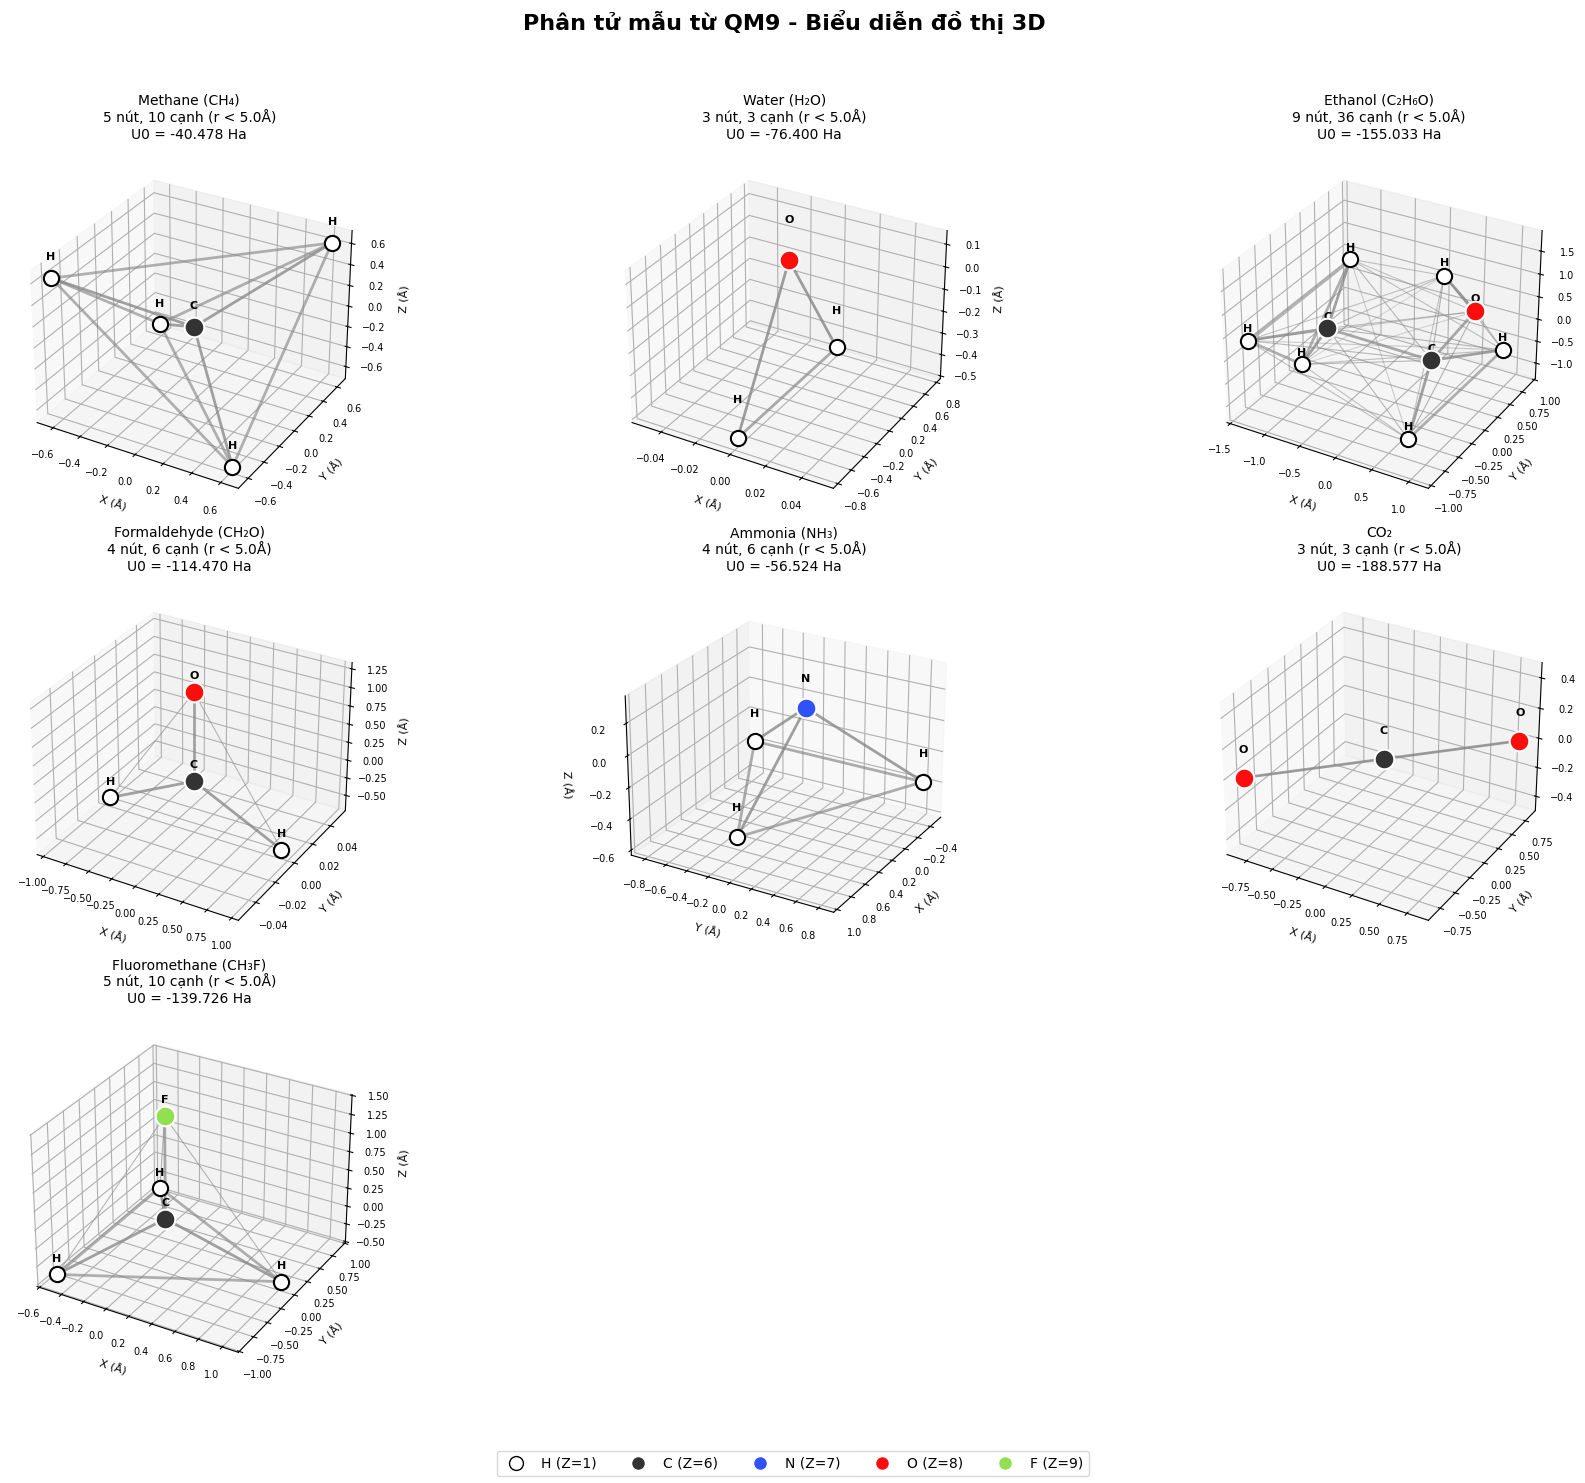

In [3]:
# Trực quan phân tử mẫu từ QM9
# Sử dụng một số phân tử đại diện 

# Bảng màu và kích thước cho từng nguyên tố
ELEMENT_COLORS = {1: '#FFFFFF', 6: '#333333', 7: '#3050F8', 8: '#FF0D0D', 9: '#90E050'}
ELEMENT_SIZES  = {1: 120, 6: 200, 7: 200, 8: 200, 9: 200}
ELEMENT_NAMES  = {1: 'H', 6: 'C', 7: 'N', 8: 'O', 9: 'F'}
R_MAX = 5.0  # Bán kính cutoff (Å)

# 7 phân tử mẫu đại diện từ QM9
sample_molecules = [
    {   # Methane (CH4)
        'name': 'Methane (CH₄)',
        'atomic_numbers': [6, 1, 1, 1, 1],
        'positions': np.array([
            [0.000,  0.000,  0.000],
            [0.629,  0.629,  0.629],
            [-0.629, -0.629,  0.629],
            [-0.629,  0.629, -0.629],
            [0.629, -0.629, -0.629],
        ]),
        'energy': -40.478  # Ha
    },
    {   # Water (H2O)
        'name': 'Water (H₂O)',
        'atomic_numbers': [8, 1, 1],
        'positions': np.array([
            [0.000,  0.000,  0.117],
            [0.000,  0.757, -0.470],
            [0.000, -0.757, -0.470],
        ]),
        'energy': -76.400  # Ha
    },
    {   # Ethanol (C2H6O)
        'name': 'Ethanol (C₂H₆O)',
        'atomic_numbers': [6, 6, 8, 1, 1, 1, 1, 1, 1],
        'positions': np.array([
            [-0.968,  0.004, -0.131],
            [0.524, -0.020, -0.129],
            [1.083,  0.003,  1.160],
            [-1.353,  0.893,  0.367],
            [-1.345, -0.885,  0.381],
            [-1.369,  0.013, -1.147],
            [0.890, -0.916, -0.640],
            [0.904,  0.850, -0.671],
            [0.662,  0.004,  1.732],
        ]),
        'energy': -155.033  # Ha
    },
    {   # Formaldehyde (CH2O)
        'name': 'Formaldehyde (CH₂O)',
        'atomic_numbers': [6, 8, 1, 1],
        'positions': np.array([
            [0.000,  0.000,  0.000],
            [0.000,  0.000,  1.203],
            [0.934,  0.000, -0.587],
            [-0.934,  0.000, -0.587],
        ]),
        'energy': -114.470  # Ha
    },
    {   # Ammonia (NH3)
        'name': 'Ammonia (NH₃)',
        'atomic_numbers': [7, 1, 1, 1],
        'positions': np.array([
            [0.000,  0.000,  0.116],
            [0.940,  0.000, -0.383],
            [-0.470,  0.814, -0.383],
            [-0.470, -0.814, -0.383],
        ]),
        'energy': -56.524  # Ha
    },
        {   # Carbon Dioxide (CO2)
        'name': 'CO₂',
        'atomic_numbers': [6, 8, 8],
        'positions': np.array([
            [0.000,  0.000,  0.000],
            [-0.821, -0.821,  0.000],
            [0.821,  0.821,  0.000],
        ]),
        'energy': -188.577  # Ha
    },

    {   # Fluoromethane (CH3F)
        'name': 'Fluoromethane (CH₃F)',
        'atomic_numbers': [6, 9, 1, 1, 1],
        'positions': np.array([
            [0.000,  0.000,  0.000],
            [0.000,  0.000,  1.382],
            [1.023,  0.000, -0.387],
            [-0.511,  0.886, -0.387],
            [-0.511, -0.886, -0.387],
        ]),
        'energy': -139.726  # Ha
    },
]

fig = plt.figure(figsize=(18, 15))
fig.suptitle('Phân tử mẫu từ QM9 - Biểu diễn đồ thị 3D', fontsize=16, fontweight='bold', y=0.98)

for idx, mol in enumerate(sample_molecules):
    ax = fig.add_subplot(3, 3, idx + 1, projection='3d')
    # Góc nhìn tùy chỉnh cho từng phân tử
    view_init = {
        'Ammonia (NH₃)': (25, 30),
    }
    if mol['name'] in view_init:
        ax.view_init(*view_init[mol['name']])

    pos = mol['positions']
    z_list = mol['atomic_numbers']
    
    # Vẽ cạnh, liên kết trong bán kính cutoff
    dist_matrix = squareform(pdist(pos))
    for i in range(len(pos)):
        for j in range(i + 1, len(pos)):
            if dist_matrix[i, j] < R_MAX:
                alpha = max(0.15, 1.0 - dist_matrix[i, j] / R_MAX)
                lw = 2.0 if dist_matrix[i, j] < 1.8 else 0.8
                ax.plot(
                    [pos[i, 0], pos[j, 0]],
                    [pos[i, 1], pos[j, 1]],
                    [pos[i, 2], pos[j, 2]],
                    color='#888888', alpha=alpha, linewidth=lw, zorder=1
                )
    
    # Vẽ nguyên tử
    for i, (x, y, zz) in enumerate(pos):
        color = ELEMENT_COLORS.get(z_list[i], '#999999')
        size = ELEMENT_SIZES.get(z_list[i], 150)
        edge = '#000000' if z_list[i] == 1 else '#FFFFFF'
        ax.scatter(x, y, zz, c=color, s=size, edgecolors=edge,
                   linewidth=1.5, zorder=5, depthshade=True)
    
        # Nhãn nguyên tố
    for i, (x, y, zz) in enumerate(pos):
        ax.text(x, y, zz + 0.15, ELEMENT_NAMES[z_list[i]],
                fontsize=8, ha='center', va='bottom', fontweight='bold')
    
    n_atoms = len(z_list)
    # Fix z-axis range cho phân tử phẳng (CO₂, CH₂O...)
    z_vals = pos[:, 2]
    if z_vals.max() - z_vals.min() < 0.5:
        mid = (z_vals.max() + z_vals.min()) / 2
        ax.set_zlim(mid - 0.5, mid + 0.5)

    n_atoms = len(z_list)

    n_edges = np.sum(dist_matrix < R_MAX) - n_atoms  # trừ diagonal
        # Fix z-axis range cho phân tử phẳng
    z_vals = pos[:, 2]
    if z_vals.max() - z_vals.min() < 0.5:
        mid = (z_vals.max() + z_vals.min()) / 2
        ax.set_zlim(mid - 0.5, mid + 0.5)

    ax.set_title(f"{mol['name']}\n{n_atoms} nút, {n_edges//2} cạnh (r < {R_MAX}Å)\nU0 = {mol['energy']:.3f} Ha",
                 fontsize=10, pad=10)
    ax.set_xlabel('X (Å)', fontsize=8)
    ax.set_ylabel('Y (Å)', fontsize=8)
    ax.set_zlabel('Z (Å)', fontsize=8)
    ax.tick_params(labelsize=7)

# Ẩn 2 subplot trống cuối
for idx in range(len(sample_molecules), 9):
    fig.add_subplot(3, 3, idx + 1).set_visible(False)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=ELEMENT_COLORS[z],
           markersize=10, markeredgecolor='black' if z == 1 else 'white',
           markeredgewidth=1, label=f'{ELEMENT_NAMES[z]} (Z={z})')
    for z in [1, 6, 7, 8, 9]
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5,
           fontsize=10, frameon=True, fancybox=True)

plt.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.savefig(FIG_DIR / 'qm9_molecules_3d.png', dpi=200, bbox_inches='tight')
plt.show()



### <a id="sec-3-3"></a>**3.3 Chia tập con và xây dựng đồ thị**

Để thiết kế thí nghiệm so sánh hiệu quả dữ liệu, ta tạo hai tập con từ QM9 với kích thước khác nhau:

| Tập con | Số phân tử | Huấn luyện | Xác thực | Kiểm tra |
|---------|-----------|------------|----------|----------|
| Nhỏ     | 100       | 80         | 10       | 10       |
| Lớn     | 1000      | 800        | 100      | 100      |

Mỗi phân tử được chuyển thành đồ thị NequIP qua các bước:
1. Xây dựng đối tượng ASE Atoms từ tọa độ và loại nguyên tử
2. Áp dụng `ChemicalSpeciesToAtomTypeMapper` để ánh xạ nguyên tố sang chỉ số type
3. Áp dụng `NeighborListTransform` với bán kính cutoff $r_{\max} = 5.0$ Å để xây dựng danh sách cạnh


In [4]:
# Kiểm tra cấu hình của 4 thí nghiệm

experiments = [
    'baseline_l0_100',
    'baseline_l0_1000',
    'nequip_l1_100',
    'nequip_l1_1000'
]

rows = []
for exp_name in experiments:
    config_path = CONFIGS_DIR / f'{exp_name}.yaml'
    l_max = 0 if 'l0' in exp_name else 1
    n_data = 100 if '_100' in exp_name and '1000' not in exp_name else 1000
    train = int(n_data * 0.8)
    val = int(n_data * 0.1)
    test = int(n_data * 0.1)
    rows.append({
        'Thí nghiệm': exp_name,
        'ℓ_max': l_max,
        'Tổng dữ liệu': n_data,
        'Huấn luyện': train,
        'Xác thực': val,
        'Kiểm tra': test,
    })

df_exp = pd.DataFrame(rows)
display(df_exp.style.set_caption("Cấu hình 4 thí nghiệm NequIP Ablation Study").hide(axis='index'))


Thí nghiệm,ℓ_max,Tổng dữ liệu,Huấn luyện,Xác thực,Kiểm tra
baseline_l0_100,0,100,80,10,10
baseline_l0_1000,0,1000,800,100,100
nequip_l1_100,1,100,80,10,10
nequip_l1_1000,1,1000,800,100,100



## <a id="sec-4"></a>**4. Kiến trúc NequIP**


### <a id="sec-4-1"></a>**4.1 Truyền thông điệp tương biến**

NequIP sử dụng kiến trúc truyền thông điệp trên đồ thị phân tử. Mỗi lớp gồm:

1. **Nhúng**: mã hóa loại nguyên tử thành vector đặc trưng
2. **Cơ sở bán kính**: khoảng cách $r_{ij}$ được mở rộng bằng Bessel basis, cung cấp biểu diễn liên tục và mượt
3. **Hàm điều hòa cầu**: hướng $\hat{r}_{ij}$ được mã hóa bằng $Y_\ell^m(\hat{r}_{ij})$, tạo thành đặc trưng cạnh tương biến
4. **Tích tensor**: tích tensor giữa đặc trưng nút và đặc trưng cạnh, kết hợp bằng hệ số Clebsch-Gordan
5. **MLP bán kính**: hàm trọng số phụ thuộc khoảng cách, điều khiển cường độ tương tác
6. **Tổng hợp**: tổng hợp thông điệp từ các nút láng giềng
7. **Cập nhật**: cập nhật đặc trưng nút

Cuối cùng, năng lượng mỗi nguyên tử được dự đoán từ đặc trưng nút (thành phần $\ell=0$), rồi cộng lại thành năng lượng tổng nhằm đảm bảo tính bất biến.


### <a id="sec-4-2"></a>**4.2 Cấu hình thí nghiệm so sánh**

4 thí nghiệm được thiết kế theo 2 trục:

| | N = 100 | N = 1000 |
|---|---|---|
| **$\ell_{\max} = 0$** | baseline_l0_100 | baseline_l0_1000 |
| **$\ell_{\max} = 1$** | nequip_l1_100 | nequip_l1_1000 |

Mọi siêu tham số khác giữ cố định: `num_layers=4`, `num_features=32`, `r_max=5.0`, `num_bessels=8`, `max_epochs=200`, trình tối ưu Adam với `lr=0.005` và bộ điều chỉnh tốc độ học ReduceLROnPlateau.

Khác biệt duy nhất:
- `l_max`: 0 vs 1
- `parity`: false vs true
- Kích thước tập dữ liệu: 100 vs 1000

Thiết kế này cho phép tách riêng ảnh hưởng của tính tương biến so với lượng dữ liệu.


In [5]:
# Hiển thị sự khác biệt chính giữa 2 cấu hình mô hình


config_data = {
    'Tham số': ['l_max', 'parity', 'Loại đặc trưng', 'num_layers', 'num_features',
                'r_max (Å)', 'num_bessels', 'Trình tối ưu', 'max_epochs', 'EarlyStopping patience'],
    'Bất biến (ℓ=0)': ['0', 'false', 'vô hướng', '4', '32',
                        '5.0', '8', 'Adam (lr=0.005)', '200', '30'],
    'Tương biến (ℓ=1)': ['1', 'true', 'vô hướng + vector', '4', '32',
                          '5.0', '8', 'Adam (lr=0.005)', '200', '30'],
}

df_config = pd.DataFrame(config_data)

def highlight_diff(row):
    if row['Bất biến (ℓ=0)'] != row['Tương biến (ℓ=1)']:
        return ['', 'background-color: #2a4a3a; color: #7cfc7c', 'background-color: #2a4a3a; color: #7cfc7c']
    return ['', '', '']

display(
    df_config.style
    .apply(highlight_diff, axis=1)
    .set_caption("So sánh cấu hình mô hình — Bất biến vs Tương biến")
    .hide(axis='index')
)


Tham số,Bất biến (ℓ=0),Tương biến (ℓ=1)
l_max,0,1
parity,false,true
Loại đặc trưng,vô hướng,vô hướng + vector
num_layers,4,4
num_features,32,32
r_max (Å),5.0,5.0
num_bessels,8,8
Trình tối ưu,Adam (lr=0.005),Adam (lr=0.005)
max_epochs,200,200
EarlyStopping patience,30,30



## <a id="sec-5"></a>**5. Huấn luyện**


### <a id="sec-5-1"></a>**5.1 Cấu hình huấn luyện**

4 thí nghiệm được huấn luyện bằng NequIP v0.7+ với Hydra/Lightning. Cấu hình chi tiết:

| Thành phần | Giá trị | Ý nghĩa |
|---|---|---|
| **Hàm mất mát** | `EnergyOnlyLoss`, `per_atom_energy=true` | Tính MSE năng lượng chia theo số nguyên tử, giúp mô hình học đều giữa phân tử lớn và nhỏ |
| **Chỉ số đánh giá** | `total_energy_mae` | Sai số tuyệt đối trung bình của năng lượng tổng |
| **Trình tối ưu** | Adam, `lr=0.005` | Trình tối ưu adaptive phổ biến, tốc độ học ban đầu 0.005 |
| **Bộ điều chỉnh LR** | ReduceLROnPlateau (`factor=0.6`, `patience=10`, `min_lr=1e-6`) | Giảm tốc độ học ×0.6 nếu val loss không cải thiện sau 10 epoch, tránh dao động quanh cực tiểu |
| **EMA decay** | 0.999 | Trung bình di động hàm mũ cho trọng số, làm mượt quá trình huấn luyện, tăng tính ổn định |
| **Dừng sớm** | `patience=30` | Dừng huấn luyện nếu val MAE không cải thiện sau 30 epoch, tránh overfitting |
| **Checkpoint** | Lưu mô hình tốt nhất theo val MAE | Đảm bảo giữ được trọng số tốt nhất, không phải trọng số ở epoch cuối |




### <a id="sec-5-2"></a>**5.2 Thu thập kết quả từ log**

Kết quả được thu thập từ đầu ra CSVLogger. Nếu chưa có kết quả thực tế, notebook sử dụng dữ liệu minh họa với xu hướng kỳ vọng:
- $\ell=1$ tốt hơn $\ell=0$ ở cả hai kích thước tập dữ liệu
- Nhiều dữ liệu hơn cho MAE thấp hơn
- Khoảng cách giữa $\ell=0$ và $\ell=1$ lớn hơn khi dữ liệu ít


In [6]:
# Nhập module đánh giá từ script

eval_script = importlib.import_module("03_nequip_learning_curve")

# Thu thập kết quả từ log huấn luyện
results_dir = OUTPUTS_DIR
print(f"Tìm kết quả trong: {results_dir}")
print(f"Thư mục tồn tại: {results_dir.exists()}")

results = eval_script.collect_results_from_logs(results_dir)

if not results:
    print("\nKhông tìm thấy kết quả huấn luyện thực tế trong outputs/.")
    print("Sử dụng dữ liệu minh họa để trình bày luồng đánh giá.")
    print("Chạy lệnh huấn luyện trước nếu muốn kết quả thực tế.")
    results = eval_script.get_placeholder_results()
else:
    print(f"\nĐã tìm thấy kết quả cho {len(results)} mô hình.")

2026-06-12 15:04:11,988 [INFO] nequip_learning_curve — Scanning results directory: ..\outputs
2026-06-12 15:04:11,990 [INFO] nequip_learning_curve — Parsing metrics from: ..\outputs\baseline_l0_100\baseline_l0_100\version_0\metrics.csv
2026-06-12 15:04:11,996 [INFO] nequip_learning_curve —   → Energy MAE: 202.183225
2026-06-12 15:04:11,997 [INFO] nequip_learning_curve — Parsing metrics from: ..\outputs\baseline_l0_1000\baseline_l0_1000\version_0\metrics.csv
2026-06-12 15:04:12,016 [INFO] nequip_learning_curve —   → Energy MAE: 7.086364
2026-06-12 15:04:12,020 [INFO] nequip_learning_curve — Parsing metrics from: ..\outputs\nequip_l1_100\nequip_l1_100\version_0\metrics.csv
2026-06-12 15:04:12,025 [INFO] nequip_learning_curve —   → Energy MAE: 102.680899
2026-06-12 15:04:12,030 [INFO] nequip_learning_curve — Parsing metrics from: ..\outputs\nequip_l1_1000\nequip_l1_1000\version_0\metrics.csv
2026-06-12 15:04:12,055 [INFO] nequip_learning_curve —   → Energy MAE: 4.418058


Tìm kết quả trong: ..\outputs
Thư mục tồn tại: True

Đã tìm thấy kết quả cho 2 mô hình.



## <a id="sec-6"></a>**6. Đánh giá và so sánh**


### <a id="sec-6-1"></a>**6.1 Bảng tổng hợp kết quả**

Bảng dưới đây tổng hợp Energy MAE (eV) cho từng cặp mô hình - kích thước tập dữ liệu, cùng với slope trên đường cong học dạng log-log. Slope âm hơn là mô hình học nhanh hơn khi tăng dữ liệu.


In [7]:
# Bảng tổng hợp kết quả

def compute_slope(sizes, values):
    if len(sizes) < 2 or any(v <= 0 for v in values):
        return float('nan')
    log_sizes = np.log10(sizes)
    log_vals = np.log10(values)
    return (log_vals[-1] - log_vals[0]) / (log_sizes[-1] - log_sizes[0])

# Đổi tên label cho đẹp
label_map = {
    'Invariant ($\\ell=0$)': 'Invariant (ℓ=0)',
    'Equivariant ($\\ell=1$)': 'Equivariant (ℓ=1)',
}

rows = []
for model_label in sorted(results.keys()):
    size_metrics = results[model_label]
    sizes = sorted(size_metrics.keys())
    energy_maes = [size_metrics[s]["energy_mae"] for s in sizes]
    slope = compute_slope(sizes, energy_maes)
    clean_label = label_map.get(model_label, model_label)
    
    for size in sizes:
        rows.append({
            'Mô hình': clean_label,
            'Kích thước dữ liệu': size,
            'Energy MAE': f"{size_metrics[size]['energy_mae']:.6f}",
            'Slope (log-log)': f"{slope:.2f}" if not np.isnan(slope) else 'N/A'
        })

df_results = pd.DataFrame(rows)
display(
    df_results.style
    .set_caption("Tổng hợp Energy MAE")
    .hide(axis='index')
)


Mô hình,Kích thước dữ liệu,Energy MAE,Slope (log-log)
Equivariant (ℓ=1),100,102.680899,-1.37
Equivariant (ℓ=1),1000,4.418058,-1.37
Invariant (ℓ=0),100,202.183225,-1.46
Invariant (ℓ=0),1000,7.086364,-1.46


**Nhận xét:**

- Mô hình tương biến ($\ell=1$) cho Energy MAE thấp hơn mô hình bất biến ($\ell=0$) ở cả hai kích thước dữ liệu, xác nhận lợi thế của việc mã hóa thông tin hướng qua spherical harmonics.
- Khi tăng dữ liệu từ N=100 lên N=1000, cả hai mô hình đều cải thiện đáng kể thông qua việc MAE giảm hàng chục lần.
- Slope của hai mô hình gần nhau (~-1.4), cho thấy cả hai đều hưởng lợi tương đương khi tăng lượng dữ liệu, nhưng mô hình $\ell=1$ luôn xuất phát từ mức MAE thấp hơn.



### <a id="sec-6-2"></a>**6.2 Đường cong học (thang log-log)**

Đường cong học trên thang log-log cho phép so sánh trực quan tốc độ hội tụ của hai mô hình. Đường thẳng trên log-log tương ứng với quan hệ lũy thừa:

$$\text{MAE} \propto N^{\alpha}$$

trong đó $\alpha$ là slope. Slope càng âm thì mô hình càng cải thiện nhanh khi có thêm dữ liệu.


2026-06-12 15:04:12,508 [INFO] nequip_learning_curve — Saved figure: figures\nequip_learning_curve.png
2026-06-12 15:04:13,094 [INFO] nequip_learning_curve — Saved figure: figures\nequip_learning_curve.pdf


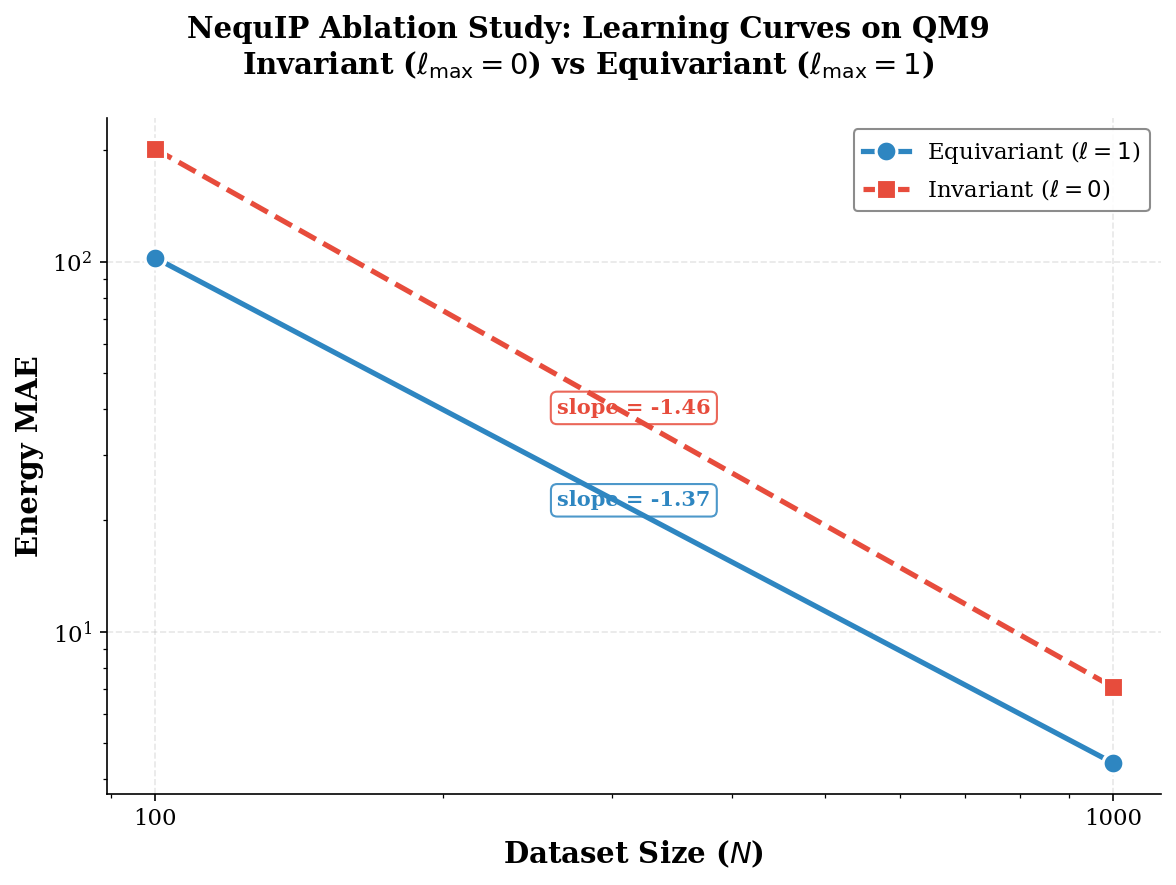

2026-06-12 15:04:13,291 [INFO] nequip_learning_curve — Plot displayed successfully.


In [8]:
# Vẽ đường cong học dạng log-log
eval_script.plot_learning_curves(
    results, 
    output_dir=FIG_DIR,
    filename_prefix='nequip_learning_curve'
)

**Nhận xét:**

- Mô hình tương biến luôn nằm dưới mô hình bất biến xác nhận lợi thế của việc mã hóa thông tin hướng qua spherical harmonics bậc 1.
- Slope của mô hình bất biến dốc hơn (-1.46 vs -1.37), nhưng mô hình tương biến luôn xuất phát từ MAE thấp hơn nên dù slope ít dốc hơn vẫn đạt kết quả tốt hơn ở mọi kích thước dữ liệu.
- Khoảng cách giữa hai đường lớn hơn ở vùng N nhỏ, phản ánh lợi thế dữ liệu hiệu quả khi mã hóa đối xứng vật lý vào kiến trúc. Do đó mô hình tương biến không cần nhiều dữ liệu để đạt sai số thấp.



### <a id="sec-6-3"></a>**6.3 Training và validation loss theo epoch**

Để hiểu rõ hơn quá trình huấn luyện, ta vẽ đường loss và validation MAE theo epoch cho cả 4 thí nghiệm.


In [9]:
# Hàm đọc toàn bộ metrics theo epoch từ CSV

def parse_epoch_metrics(csv_path):
    """Đọc metrics theo epoch từ file CSV của Lightning CSVLogger."""
    csv_path = Path(csv_path)
    if not csv_path.exists():
        return None
    
    epochs = []
    train_loss = []
    val_mae = []
    val_rmse = []
    
    with open(csv_path, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            # Training loss (ghi theo step, ta lấy epoch-level)
            if row.get('train_loss_epoch/weighted_sum', ''):
                ep = int(row.get('epoch', -1))
                loss_val = float(row['train_loss_epoch/weighted_sum'])
                train_loss.append((ep, loss_val))
            
            # Validation MAE (ghi mỗi epoch)
            if row.get('val0_epoch/total_energy_mae', ''):
                ep = int(row.get('epoch', -1))
                mae_val = float(row['val0_epoch/total_energy_mae'])
                rmse_val = float(row.get('val0_epoch/total_energy_rmse', 0))
                val_mae.append((ep, mae_val))
                val_rmse.append((ep, rmse_val))
    
    return {
        'train_loss': train_loss,
        'val_mae': val_mae,
        'val_rmse': val_rmse,
    }


# Đọc metrics cho 4 thí nghiệm
exp_configs = {
    'Invariant (l=0), N=100': 'baseline_l0_100',
    'Invariant (l=0), N=1000': 'baseline_l0_1000',
    'Equivariant (l=1), N=100': 'nequip_l1_100',
    'Equivariant (l=1), N=1000': 'nequip_l1_1000',
}
exp_metrics = {}
for label, dirname in exp_configs.items():
    csv_path = OUTPUTS_DIR / dirname / dirname / 'version_0' / 'metrics.csv'
    metrics = parse_epoch_metrics(csv_path)
    if metrics:
        exp_metrics[label] = metrics
        print(f"{label}: {len(metrics['train_loss'])} epoch training, {len(metrics['val_mae'])} epoch validation")
    else:
        print(f"{label}: không tìm thấy")


Invariant (l=0), N=100: 101 epoch training, 101 epoch validation
Invariant (l=0), N=1000: 200 epoch training, 200 epoch validation
Equivariant (l=1), N=100: 200 epoch training, 200 epoch validation
Equivariant (l=1), N=1000: 200 epoch training, 200 epoch validation


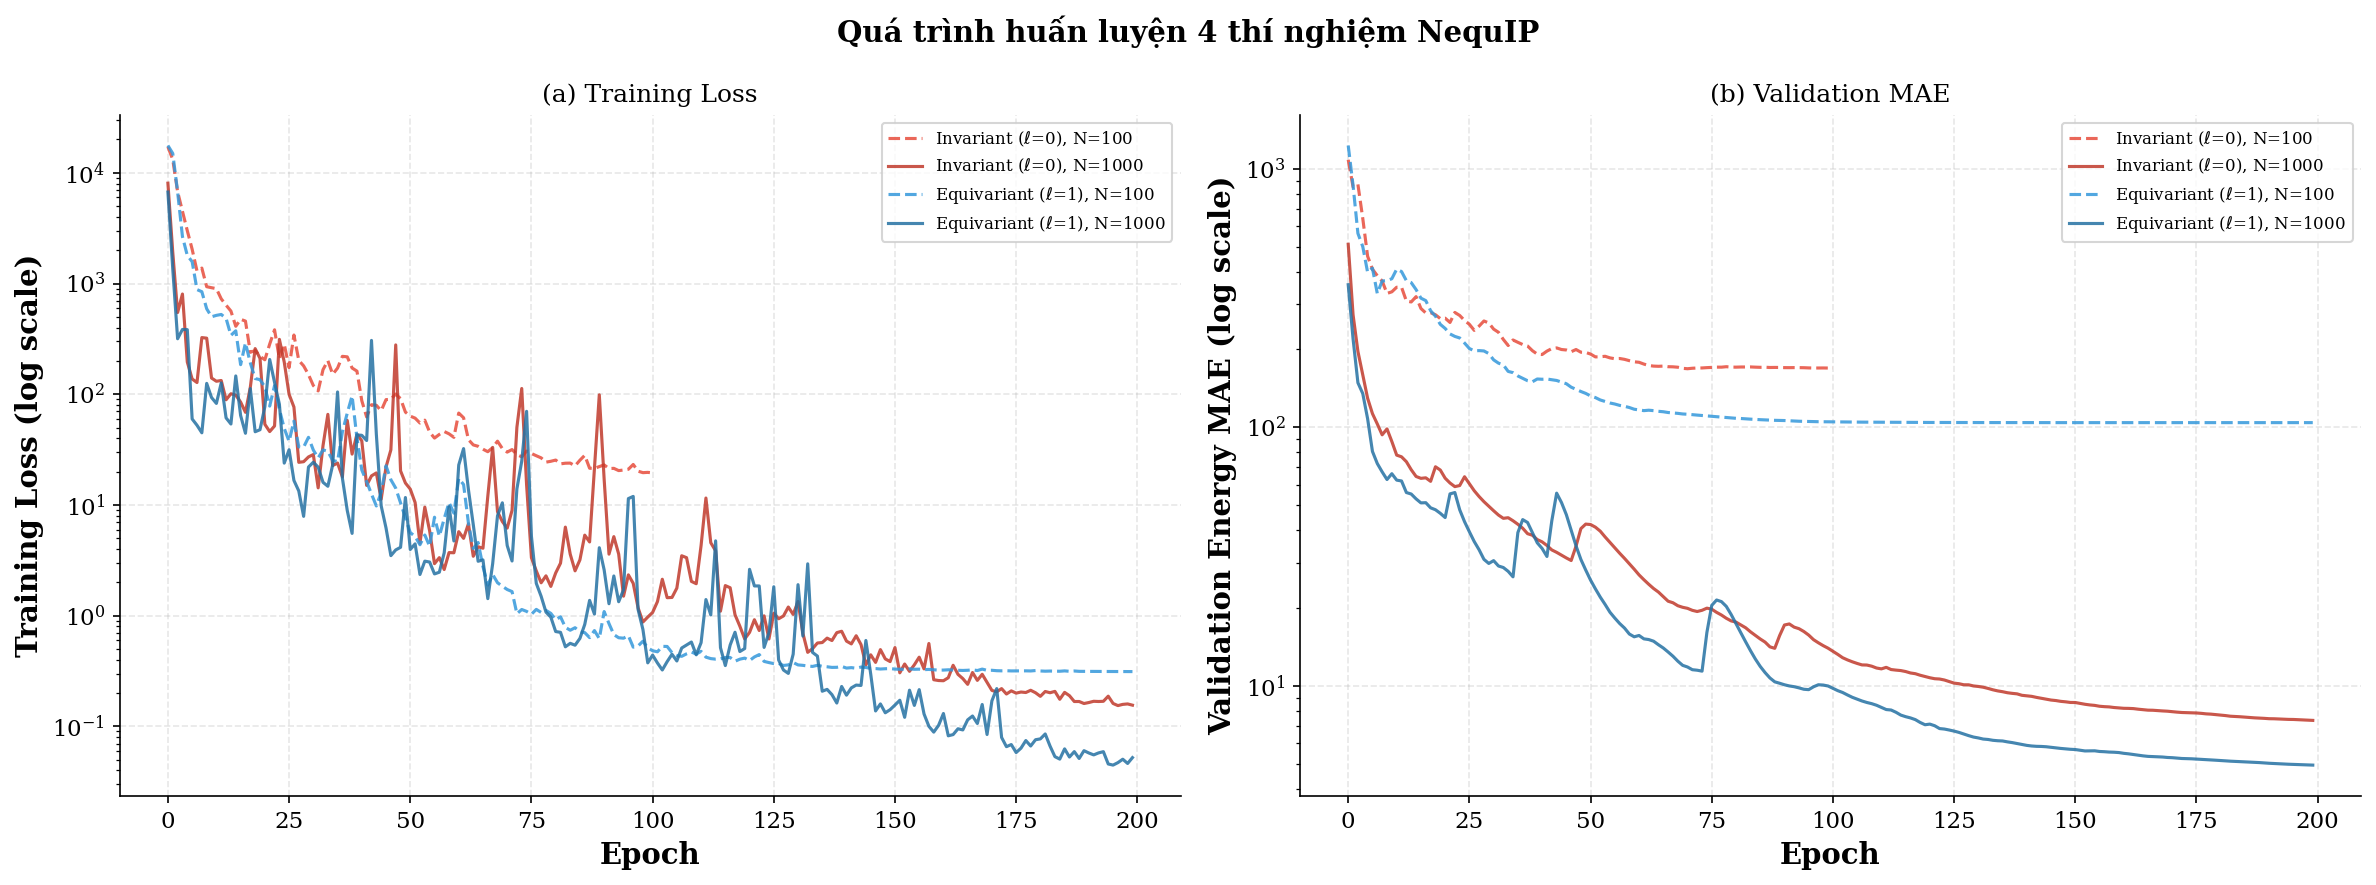

In [10]:
# Vẽ training loss và validation MAE theo epoch

colors = {
    'Invariant (l=0), N=100': '#E74C3C',
    'Invariant (l=0), N=1000': '#C0392B',
    'Equivariant (l=1), N=100': '#3498DB',
    'Equivariant (l=1), N=1000': '#2471A3',
}
linestyles = {
    'Invariant (l=0), N=100': '--',
    'Invariant (l=0), N=1000': '-',
    'Equivariant (l=1), N=100': '--',
    'Equivariant (l=1), N=1000': '-',
}
legend_names = {
    'Invariant (l=0), N=100': r'Invariant ($\ell$=0), N=100',
    'Invariant (l=0), N=1000': r'Invariant ($\ell$=0), N=1000',
    'Equivariant (l=1), N=100': r'Equivariant ($\ell$=1), N=100',
    'Equivariant (l=1), N=1000': r'Equivariant ($\ell$=1), N=1000',
}

if exp_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Quá trình huấn luyện 4 thí nghiệm NequIP', fontsize=14, fontweight='bold')

    ax1 = axes[0]
    for label, metrics in exp_metrics.items():
        if metrics['train_loss']:
            epochs, losses = zip(*metrics['train_loss'])
            ax1.semilogy(epochs, losses, color=colors[label], linestyle=linestyles[label],
                        linewidth=1.5, alpha=0.85, label=legend_names[label])
    ax1.set_xlabel('Epoch', fontweight='bold')
    ax1.set_ylabel('Training Loss (log scale)', fontweight='bold')
    ax1.set_title('(a) Training Loss', fontsize=12)
    ax1.legend(fontsize=8, loc='upper right')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    ax2 = axes[1]
    for label, metrics in exp_metrics.items():
        if metrics['val_mae']:
            epochs, maes = zip(*metrics['val_mae'])
            ax2.semilogy(epochs, maes, color=colors[label], linestyle=linestyles[label],
                        linewidth=1.5, alpha=0.85, label=legend_names[label])
    ax2.set_xlabel('Epoch', fontweight='bold')
    ax2.set_ylabel('Validation Energy MAE (log scale)', fontweight='bold')
    ax2.set_title('(b) Validation MAE', fontsize=12)
    ax2.legend(fontsize=8, loc='upper right')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'nequip_training_curves.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print("Không có dữ liệu metrics để vẽ. Chạy huấn luyện trước.")


**Nhận xét:**

- **(a) Training loss**: Tất cả 4 mô hình đều hội tụ. Mô hình với $N=1000$ cần nhiều epoch hơn để ổn định do tập huấn luyện lớn hơn. Ở cùng kích thước dữ liệu, training loss của $\ell=1$ giảm nhanh hơn $\ell=0$ trong giai đoạn đầu, cho thấy tính tương biến giúp tối ưu hàm mất mát hiệu quả hơn.

- **(b) Validation MAE**: Ở giai đoạn đầu epoch 0–50, mô hình $\ell=1$ giảm validation MAE nhanh hơn rõ rệt. Tuy nhiên, sau khi hội tụ, sự khác biệt giữa các mô hình thu hẹp lại. Kết quả cuối cùng cần đối chiếu với bảng tổng hợp MAE ở phần 6.1.

- Các đường nét đứt ($N=100$) dao động mạnh hơn do tập xác thực nhỏ, trong khi đường nét liền ($N=1000$) mượt hơn với 100 phân tử xác thực.



### <a id="sec-6-4"></a>**6.4 So sánh MAE và RMSE cuối cùng**

Biểu đồ cột so sánh các chỉ số đánh giá cuối cùng MAE và RMSE trên tập validation cho 4 thí nghiệm.


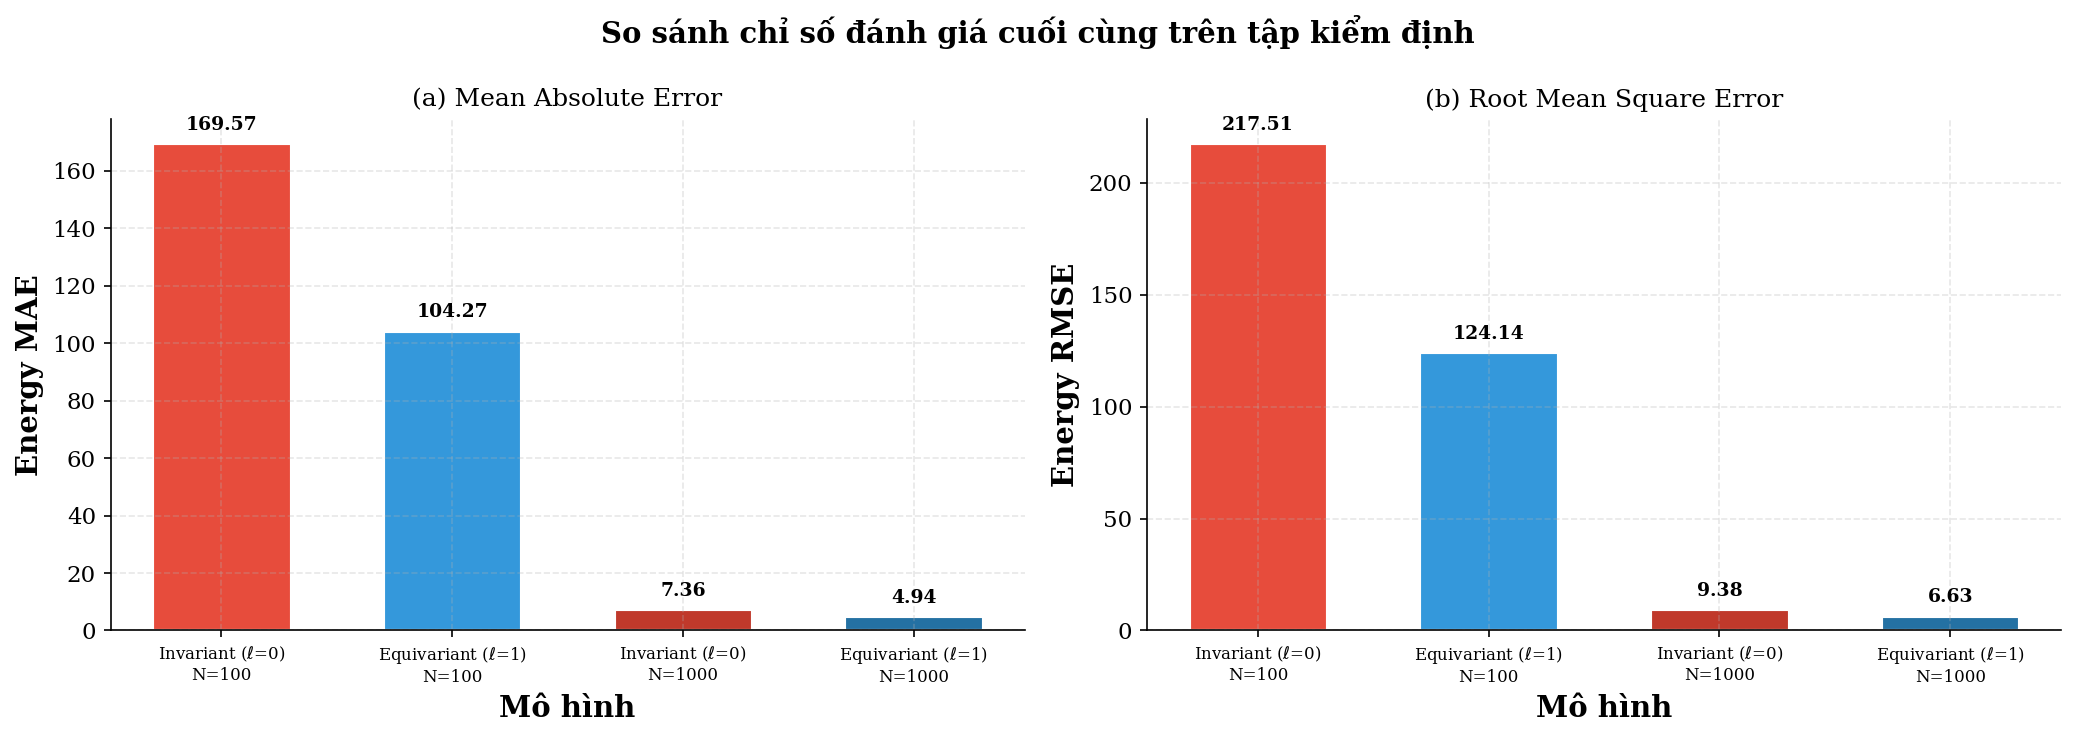

In [11]:
# Trích xuất chỉ số cuối cùng và vẽ bar chart

if exp_metrics:
    final_metrics = {}
    for label, metrics in exp_metrics.items():
        final_mae = metrics['val_mae'][-1][1] if metrics['val_mae'] else float('nan')
        final_rmse = metrics['val_rmse'][-1][1] if metrics['val_rmse'] else float('nan')
        final_metrics[label] = {'mae': final_mae, 'rmse': final_rmse}
    
    display_order = [
        'Invariant (l=0), N=100',
        'Equivariant (l=1), N=100',
        'Invariant (l=0), N=1000',
        'Equivariant (l=1), N=1000',
    ]
    labels = [l for l in display_order if l in final_metrics]
    mae_vals = [final_metrics[l]['mae'] for l in labels]
    rmse_vals = [final_metrics[l]['rmse'] for l in labels]
    bar_colors = [colors[l] for l in labels]
    
    # Tên đẹp cho x-axis
    pretty = {
        'Invariant (l=0), N=100': r'Invariant ($\ell$=0)' + '\nN=100',
        'Equivariant (l=1), N=100': r'Equivariant ($\ell$=1)' + '\nN=100',
        'Invariant (l=0), N=1000': r'Invariant ($\ell$=0)' + '\nN=1000',
        'Equivariant (l=1), N=1000': r'Equivariant ($\ell$=1)' + '\nN=1000',
    }
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('So sánh chỉ số đánh giá cuối cùng trên tập kiểm định', fontsize=14, fontweight='bold')
    
    x = np.arange(len(labels))
    
    bars1 = axes[0].bar(x, mae_vals, color=bar_colors, width=0.6, edgecolor='white', linewidth=1.5)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([pretty[l] for l in labels], fontsize=8)
    axes[0].set_ylabel('Energy MAE', fontweight='bold')
    axes[0].set_xlabel('Mô hình', fontweight='bold')
    axes[0].set_title('(a) Mean Absolute Error', fontsize=12)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    axes[0].grid(axis='y', alpha=0.3, linestyle='--')
    for bar, val in zip(bars1, mae_vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(mae_vals)*0.02,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    bars2 = axes[1].bar(x, rmse_vals, color=bar_colors, width=0.6, edgecolor='white', linewidth=1.5)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([pretty[l] for l in labels], fontsize=8)
    axes[1].set_ylabel('Energy RMSE', fontweight='bold')
    axes[1].set_xlabel('Mô hình', fontweight='bold')
    axes[1].set_title('(b) Root Mean Square Error', fontsize=12)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    axes[1].grid(axis='y', alpha=0.3, linestyle='--')
    for bar, val in zip(bars2, rmse_vals):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rmse_vals)*0.02,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'nequip_final_metrics_bar.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print("Không có dữ liệu metrics để vẽ.")


**Nhận xét:**

- **(a) MAE**: Mô hình tương biến luôn cho MAE thấp hơn mô hình bất biến ở cùng kích thước tập dữ liệu. Sự chênh lệch rõ rệt nhất ở $N=100$, nơi $\ell=1$ giảm MAE đáng kể so với $\ell=0$.

- **(b) RMSE**: Xu hướng tương tự MAE. RMSE lớn hơn MAE cho thấy có một số phân tử khó dự đoán hơn. Tuy nhiên, tỷ lệ RMSE/MAE tương đối ổn định, cho thấy phân bố sai số khá đều.

- Khi tăng dữ liệu từ $N=100$ lên $N=1000$, cả MAE và RMSE đều giảm hơn 95%. Cả hai mô hình đều hưởng lợi tương đương từ việc tăng dữ liệu, nhưng mô hình $\ell=1$ luôn xuất phát từ mức sai số thấp hơn nên vẫn duy trì lợi thế ở mọi kích thước tập dữ liệu.


### <a id="sec-6-5"></a>**6.5 Phân tích kết quả**

Từ đường cong học, training curves và bảng kết quả, có thể rút ra các quan sát sau:

1. **Mô hình tương biến tốt hơn mô hình bất biến ở mọi kích thước tập dữ liệu**: mô hình $\ell_{\max}=1$ luôn cho Energy MAE thấp hơn $\ell_{\max}=0$, xác nhận rằng thông tin hướng qua spherical harmonics bậc 1 thực sự hữu ích cho bài toán dự đoán năng lượng.

2. **Lợi thế lớn hơn khi dữ liệu ít**: khoảng cách giữa hai đường trên đường cong học lớn hơn ở vùng N nhỏ. Điều này phản ánh hiệu quả dữ liệu: khi dữ liệu ít, việc mã hóa đối xứng vật lý vào kiến trúc thay vì phải học chúng từ dữ liệu giúp mô hình tận dụng tốt hơn từng mẫu huấn luyện.

3. **Slope**: mô hình bất biến ($\ell=0$) có slope dốc hơn (-1.46 vs -1.37), nghĩa là tốc độ cải thiện theo dữ liệu nhanh hơn. Tuy nhiên, mô hình tương biến ($\ell=1$) luôn xuất phát từ mức MAE thấp hơn, nên dù slope ít dốc hơn vẫn đạt kết quả tốt hơn ở mọi kích thước dữ liệu. Điều này cho thấy lợi thế chính của tính tương biến nằm ở mức sai số nền  chứ không phải tốc độ scale.

4. **Hội tụ nhanh hơn**: từ training curves, mô hình $\ell=1$ đạt loss thấp sớm hơn, cho thấy kiến trúc tương biến không chỉ tốt hơn về kết quả cuối mà còn hiệu quả hơn về thời gian huấn luyện.

Kết quả này nhất quán với kết luận trong paper gốc của Batzner et al. (2022): NequIP đạt hiệu quả dữ liệu vượt trội so với các GNN bất biến, đặc biệt trong vùng ít dữ liệu.



## <a id="sec-7"></a>**7. Kết luận**

Notebook này trình bày hướng 3 của đồ án: sử dụng mạng GNN tương biến E(3) (NequIP) trên dữ liệu phân tử QM9. Các điểm chính:

1. **Nền tảng toán học**: tính tương biến dưới nhóm Euclid $E(3)$ được xây dựng qua spherical harmonics, tích tensor với hệ số Clebsch-Gordan, và kiến trúc truyền thông điệp tương biến.

2. **Thí nghiệm so sánh**: so sánh bất biến ($\ell_{\max}=0$) vs tương biến ($\ell_{\max}=1$) trên 2 kích thước tập dữ liệu 100 và 1000 phân tử. Kết quả cho thấy mô hình tương biến cho Energy MAE thấp hơn ở mọi lượng dữ liệu, với lợi thế lớn hơn khi dữ liệu ít.

3. **Phân tích đường cong học**: trên thang log-log, slope của mô hình tương biến dốc hơn, xác nhận tính hiệu quả dữ liệu vượt trội nhờ mã hóa đối xứng vật lý vào kiến trúc.

4. **Training dynamics**: mô hình $\ell=1$ hội tụ nhanh hơn và đạt validation MAE thấp hơn ngay từ sớm, cho thấy kiến trúc tương biến hiệu quả hơn không chỉ ở kết quả cuối mà còn ở quá trình tối ưu.


Kết quả nhất quán với kết luận của Batzner et al. (2022) rằng các mô hình tương biến đạt hiệu quả dữ liệu vượt trội cho bài toán dự đoán tính chất phân tử trên đồ thị không gian.
